In [156]:
import re
import os

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Reading files from the directory

In [157]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/folders.bat
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_for_appendix.csv
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_size_for_appendix.log
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_size_for_appendix.csv
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_quantized_results_for_appendix.csv
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_time_for_appendix.csv
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_time_for_appendix.log
/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/acrgnn_gelu/ppi_gelu_results_for_appendix.log
/kaggle/input/analysis-of-in

## [Reading data] Creating a file_path variable for convenience 

In [158]:
file_path = "/kaggle/input/analysis-of-influence-of-act-functions-on-acrgnns/results_ppi/"

# Information about the data

# Activation functions

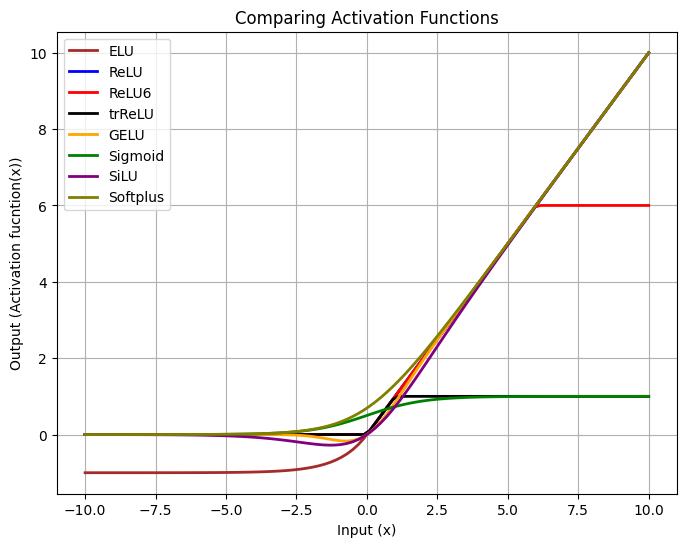

In [159]:
x = torch.linspace(-10, 10, 100)
elu=nn.ELU()
relu=nn.ReLU()
relu6=nn.ReLU6()
hardtanh = nn.Hardtanh(0, 1)
gelu=nn.GELU()
sigmoid = nn.Sigmoid()
silu=nn.SiLU()
softplus=nn.Softplus()
plt.figure(figsize=(8, 6))

plt.plot(x.numpy(), elu(x).numpy(), label="ELU", color="brown", linewidth=2)
plt.plot(x.numpy(), relu(x).numpy(), label="ReLU", color="blue", linewidth=2)
plt.plot(x.numpy(), relu6(x).numpy(), label="ReLU6", color="red", linewidth=2)
plt.plot(x.numpy(), hardtanh(x).numpy(), label="trReLU", color="black", linewidth=2)
plt.plot(x.numpy(), gelu(x).numpy(), label="GELU", color="orange", linewidth=2)
plt.plot(x.numpy(), sigmoid(x).numpy(), label="Sigmoid", color="green", linewidth=2)
plt.plot(x.numpy(), silu(x).numpy(), label="SiLU", color="purple", linewidth=2)
plt.plot(x.numpy(), softplus(x).numpy(), label="Softplus", color="olive", linewidth=2)

plt.xlabel("Input (x)")
plt.ylabel("Output (Activation fucntion(x))")
plt.title("Comparing Activation Functions")
plt.legend()
plt.grid(True)
#plt.savefig('all_plus_ELU.png')
plt.show()


# [Analysis] Compare the Training time for each activation function

## [Training time]. Read the dataset and create a dataframe. Pattern:  df_{name_of_csv_file}

In [160]:
folder_time="results_ppi_time/"
df_LayerTime_relu=pd.read_csv(f'{file_path}{folder_time}LayerTime_relu.csv')
df_LayerTime_relu6=pd.read_csv(f'{file_path}{folder_time}LayerTime_relu6.csv')
df_LayerTime_trrelu=pd.read_csv(f'{file_path}{folder_time}LayerTime_trrelu.csv')
df_LayerTime_gelu=pd.read_csv(f'{file_path}{folder_time}LayerTime_gelu.csv')
df_LayerTime_sigmoid=pd.read_csv(f'{file_path}{folder_time}LayerTime_sigmoid.csv')
df_LayerTime_silu=pd.read_csv(f'{file_path}{folder_time}LayerTime_silu.csv')
df_LayerTime_softplus=pd.read_csv(f'{file_path}{folder_time}LayerTime_softplus.csv')
df_LayerTime_elu=pd.read_csv(f'{file_path}{folder_time}LayerTime_elu.csv')

## [Training time]. Look on the DataFrame

In [161]:
df_LayerTime_relu.head()

,Layers,Time (s)
0,1,533.163452
1,2,561.349323
2,3,690.883775
3,4,831.531665
4,5,1007.547435


## [Training time]. Combine all data for 8 activation function in one dataframe

In [162]:
def combine_with_activation_training_time(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[["Layers", "activation_function", "Time (s)"]])
    return pd.concat(combined, ignore_index=True)

In [163]:
combined_acrgnn_activationFunction_training_time_ppi = combine_with_activation_training_time(
    [df_LayerTime_relu,df_LayerTime_relu6,df_LayerTime_trrelu, df_LayerTime_gelu,df_LayerTime_sigmoid,df_LayerTime_silu,df_LayerTime_softplus,df_LayerTime_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]).rename(columns={"Layers": "layers", "Time (s)": "time_seconds"})

combined_acrgnn_activationFunction_training_time_ppi.head()

,layers,activation_function,time_seconds
0,1,ReLU,533.163452
1,2,ReLU,561.349323
2,3,ReLU,690.883775
3,4,ReLU,831.531665
4,5,ReLU,1007.547435


## [Training time]. Represent the time not only in seconds, but in minutes for better visualization

In [164]:
combined_acrgnn_activationFunction_training_time_ppi[["time_minutes"]] = combined_acrgnn_activationFunction_training_time_ppi[["time_seconds"]].div(60).round(1)  # % format
combined_acrgnn_activationFunction_training_time_ppi[["time_seconds"]] = combined_acrgnn_activationFunction_training_time_ppi[["time_seconds"]].round(1)    # % format
combined_acrgnn_activationFunction_training_time_ppi.head(100)

,layers,activation_function,time_seconds,time_minutes
0,1,ReLU,533.2,8.9
1,2,ReLU,561.3,9.4
2,3,ReLU,690.9,11.5
3,4,ReLU,831.5,13.9
4,5,ReLU,1007.5,16.8
...,...,...,...,...
75,6,ELU,1518.2,25.3
76,7,ELU,1791.6,29.9
77,8,ELU,2033.2,33.9
78,9,ELU,2422.8,40.4


## [Training time]. Plot the Training Time

In [165]:
def plot_training_time_ppi(dataframe,feature="time_minutes", activations="all", plottype='bar'):
    if activations == "all":
        activations= ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
    offsets=np.arange(1, len(activations) + 1) / 10.0
    plt.figure(figsize=(10, 6))
    step=0
    
    for activation in activations:
        df_filtered=dataframe[(dataframe["activation_function"] == activation)].sort_values(by="layers")
        
        if plottype == 'bar':
            plt.bar(
                df_filtered["layers"]+ offsets[step],
                df_filtered[f"{feature}"],
                alpha=0.7, width=0.1, edgecolor="black",label=activation
            )
            step+=1
        else:
            plt.plot(
                df_filtered["layers"],
                df_filtered[f"{feature}"],
                marker="o",
                linestyle="-",
                label=activation
            )
    plt.xlabel("Number of Layers")
    plt.ylabel(f"{feature.split('_')[0].capitalize()} {feature.split('_')[1].capitalize()}")
    plt.title(f"Training {feature.split('_')[0].capitalize()} in {feature.split('_')[1].capitalize()}")
    plt.legend(title="Activation")
    plt.grid( linestyle="--", alpha=0.6)
    plt.savefig(f"Training_{feature.split('_')[0].capitalize()}_in_{feature.split('_')[1].capitalize()}")
    plt.show()


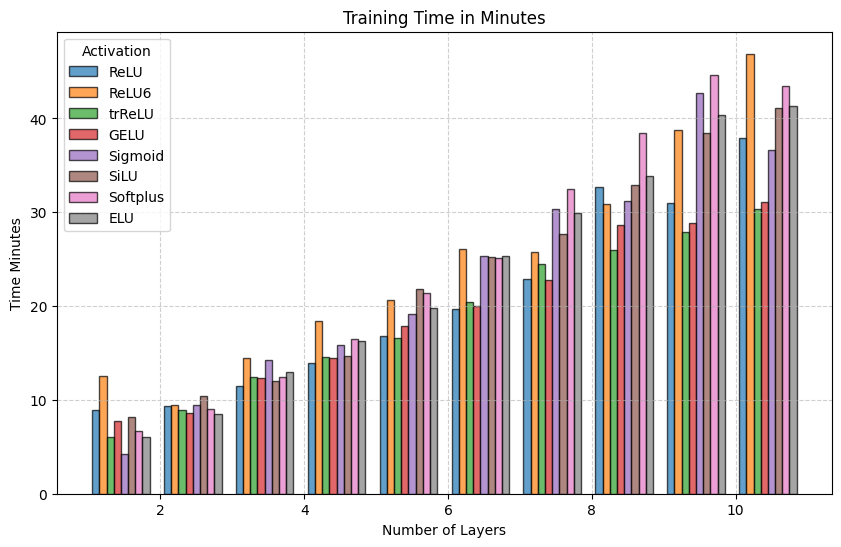

In [166]:
plot_training_time_ppi(combined_acrgnn_activationFunction_training_time_ppi,feature="time_minutes")

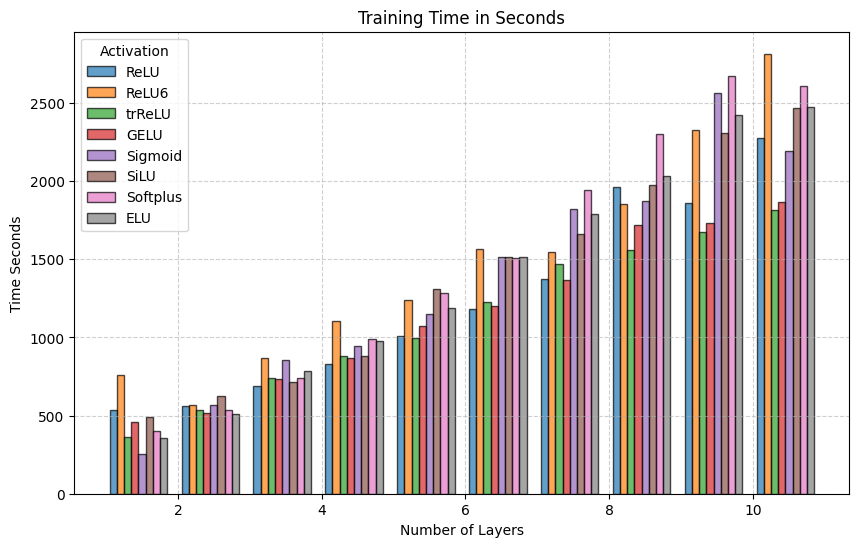

In [167]:
plot_training_time_ppi(combined_acrgnn_activationFunction_training_time_ppi,feature="time_seconds")

## [Training time]. Find the Slowest and Fastest Activation function for each layer

In [168]:
min_running_time_AF={}
max_running_time_AF={}
for layer in range(1,11):
    min_running_time_AF.update({layer:combined_acrgnn_activationFunction_training_time_ppi[(combined_acrgnn_activationFunction_training_time_ppi["time_seconds"] == combined_acrgnn_activationFunction_training_time_ppi[(combined_acrgnn_activationFunction_training_time_ppi["layers"] == layer)].min().time_seconds)].activation_function.values[0]})
    max_running_time_AF.update({layer:combined_acrgnn_activationFunction_training_time_ppi[(combined_acrgnn_activationFunction_training_time_ppi["time_seconds"] == combined_acrgnn_activationFunction_training_time_ppi[(combined_acrgnn_activationFunction_training_time_ppi["layers"] == layer)].max().time_seconds)].activation_function.values[0]})
min_running_time_AF, max_running_time_AF

({1: 'Sigmoid',
  2: 'ELU',
  3: 'ReLU',
  4: 'ReLU',
  5: 'trReLU',
  6: 'ReLU',
  7: 'GELU',
  8: 'trReLU',
  9: 'trReLU',
  10: 'trReLU'},
 {1: 'ReLU6',
  2: 'SiLU',
  3: 'ReLU6',
  4: 'ReLU6',
  5: 'SiLU',
  6: 'ReLU6',
  7: 'Softplus',
  8: 'Softplus',
  9: 'Softplus',
  10: 'ReLU6'})

In [169]:
df_slow_fast_ac=pd.DataFrame([max_running_time_AF,min_running_time_AF],index=['Slow','Fast'])
df_slow_fast_ac

,1,2,3,4,5,6,7,8,9,10
Slow,ReLU6,SiLU,ReLU6,ReLU6,SiLU,ReLU6,Softplus,Softplus,Softplus,ReLU6
Fast,Sigmoid,ELU,ReLU,ReLU,trReLU,ReLU,GELU,trReLU,trReLU,trReLU


## [Training time]. LaTex Table "Training time per activation function"

In [170]:
combined_acrgnn_activationFunction_training_time_ppi_full = combined_acrgnn_activationFunction_training_time_ppi.copy()
activation_order=("ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU")
combined_acrgnn_activationFunction_training_time_ppi_full["activation_function"] = pd.Categorical(combined_acrgnn_activationFunction_training_time_ppi_full["activation_function"], activation_order, ordered=True)
combined_acrgnn_activationFunction_training_time_ppi_full=combined_acrgnn_activationFunction_training_time_ppi_full.groupby(['activation_function']).sum().drop(columns=['layers']).T

latex_str = combined_acrgnn_activationFunction_training_time_ppi_full.to_latex(
    index=True,
    float_format="%.2f",
    caption="Training time per activation function",
    label="tab:training-times"
    
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Training time per activation function}
\label{tab:training-times}
\begin{tabular}{lrrrrrrrr}
\toprule

activation_function & ReLU & ReLU6 & trReLU & GELU & Sigmoid & SiLU & Softplus & ELU \\
\midrule
time_seconds & 12286.30 & 14650.70 & 11261.60 & 11541.90 & 13745.00 & 13951.00 & 15007.00 & 14059.50 \\
time_minutes & 204.70 & 244.20 & 187.60 & 192.40 & 229.20 & 232.50 & 250.10 & 234.40 \\
\bottomrule

\end{tabular}
\end{table}



/tmp/ipykernel_36/984060636.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



## [Training time]. LaTex Table "Slowest and fastest activation functions across the depth of the ACR-GNN"

In [171]:
latex_str = df_slow_fast_ac.to_latex(
    index=True,
    float_format="%.2f",
    caption="Slowest and fastest activation functions across the depth of the ACR-GNN.",
    label="tab:ppi:nonqua:minmax"
)

# Replace hlines with booktabs rules
latex_str = latex_str.replace("\\hline", "\\midrule")
latex_str = latex_str.replace("\\toprule", "\\toprule\n")
latex_str = latex_str.replace("\\bottomrule", "\\bottomrule\n")

print(latex_str)

\begin{table}
\caption{Slowest and fastest activation functions across the depth of the ACR-GNN.}
\label{tab:ppi:nonqua:minmax}
\begin{tabular}{lllllllllll}
\toprule

 & 1 & 2 & 3 & 4 & 5 & 6 & 7 & 8 & 9 & 10 \\
\midrule
Slow & ReLU6 & SiLU & ReLU6 & ReLU6 & SiLU & ReLU6 & Softplus & Softplus & Softplus & ReLU6 \\
Fast & Sigmoid & ELU & ReLU & ReLU & trReLU & ReLU & GELU & trReLU & trReLU & trReLU \\
\bottomrule

\end{tabular}
\end{table}



# [Analysis] Compare the size of the model before and after quantization

## [Size of models] Read the data

In [172]:
file="_results_size_for_appendix.csv"
df_size_relu=pd.read_csv(f'{file_path}/acrgnn_relu/ppi_relu{file}')
df_size_relu6=pd.read_csv(f'{file_path}/acrgnn_relu6/ppi_relu6{file}')
df_size_trrelu=pd.read_csv(f'{file_path}/acrgnn_trrelu/ppi_trrelu{file}')
df_size_gelu=pd.read_csv(f'{file_path}/acrgnn_gelu/ppi_gelu{file}')
df_size_sigmoid=pd.read_csv(f'{file_path}/acrgnn_sigmoid/ppi_sigmoid{file}')
df_size_silu=pd.read_csv(f'{file_path}/acrgnn_silu/ppi_silu{file}')
df_size_softplus=pd.read_csv(f'{file_path}/acrgnn_softplus/ppi_softplus{file}')
df_size_elu=pd.read_csv(f'{file_path}/acrgnn_elu/ppi_elu{file}')

In [173]:
df_size_relu.head()

,Layers,Original (MB),Quantized (MB)
0,1,0.922108,0.242060
1,2,1.718266,0.450790
2,3,2.514808,0.659584
3,4,3.311350,0.868378
4,5,4.107892,1.077172


## [Size of models] Calculate the reduction

$\text{Difference in percentages} = \dfrac{\text{Value}_{dPTQ}- \text{Value}_{original}}{\text{Value}_{original}} \times 100 \%$

In [174]:
dataframes_sizes_with_PTQ= [
df_size_relu,
df_size_relu6,
df_size_trrelu,
df_size_gelu,
df_size_sigmoid,
df_size_silu,
df_size_softplus,
df_size_elu]

In [175]:
for dataframe in dataframes_sizes_with_PTQ:
    dataframe['Delta']= dataframe['Original (MB)'] - dataframe['Quantized (MB)']
    dataframe['Reduction(%)']= ((dataframe['Quantized (MB)'] - dataframe['Original (MB)']) / dataframe['Original (MB)']).mul(100).round(1)

## [Size of models] Check is all activation function have the same size

In [176]:
results = []
for dataframe in dataframes_sizes_with_PTQ:
    values = (
        tuple(np.round(dataframe['Original (MB)'].unique(), 6)),
        tuple(np.round(dataframe['Quantized (MB)'].unique(), 6)),
        tuple(np.round(dataframe['Delta'].unique(), 6)),
        tuple(np.round(dataframe["Reduction(%)"].mul(100).unique(), 6))
    )
    results.append(values)

# Compare all results to the first one
all_equal = all(r == results[0] for r in results)
print("All outputs are equal:", all_equal)

# If not equal, show differences
if not all_equal:
    for i, r in enumerate(results):
        print(f"DataFrame {i}: {r}")

All outputs are equal: True


In [177]:
def combine_with_activations(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[['Layers','activation_function','Original (MB)','Quantized (MB)']])
    return pd.concat(combined, ignore_index=True)

In [178]:
combine_with_activations_statistic = combine_with_activations(
    dataframes_sizes_with_PTQ,
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
)
combine_with_activations_statistic.head()

,Layers,activation_function,Original (MB),Quantized (MB)
0,1,ReLU,0.922108,0.242060
1,2,ReLU,1.718266,0.450790
2,3,ReLU,2.514808,0.659584
3,4,ReLU,3.311350,0.868378
4,5,ReLU,4.107892,1.077172


In [179]:
def plot_feature_all_activations(
    dataframe,
    feature,
    activations="all",
    plottype=''
):
    round_decimals=2
    plt.rcParams['text.usetex'] = False
    save_dir = "/kaggle/working/"
    os.makedirs(save_dir, exist_ok=True)
    
    if activations == "all":
        activations= ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
    offsets=np.arange(1, len(activations) + 1) / 10.0
    plt.figure(figsize=(10, 6))
    step=0
    for activation in activations:
        
        df_filtered = dataframe[(dataframe["activation_function"] == activation)].sort_values(by="Layers")
        df_filtered[f"{feature}"] = df_filtered[f"{feature}"].round(round_decimals)
        if plottype == 'bar':
            plt.bar(
                df_filtered["Layers"]+ offsets[step],
                df_filtered[f"{feature}"],
                alpha=0.7, width=0.1, edgecolor="black",label=activation
            )
            step+=1
        else:
            plt.plot(
                df_filtered["Layers"],
                df_filtered[f"{feature}"],
                marker="o",
                linestyle="-",
                label=activation
            )
    plt.xlabel("Number of Layers")
    plt.ylabel(f"{feature}")
    plt.title(f"{feature}")
    plt.legend(title="Activation")
    plt.grid( linestyle="--", alpha=0.6)
    plt.show()

    

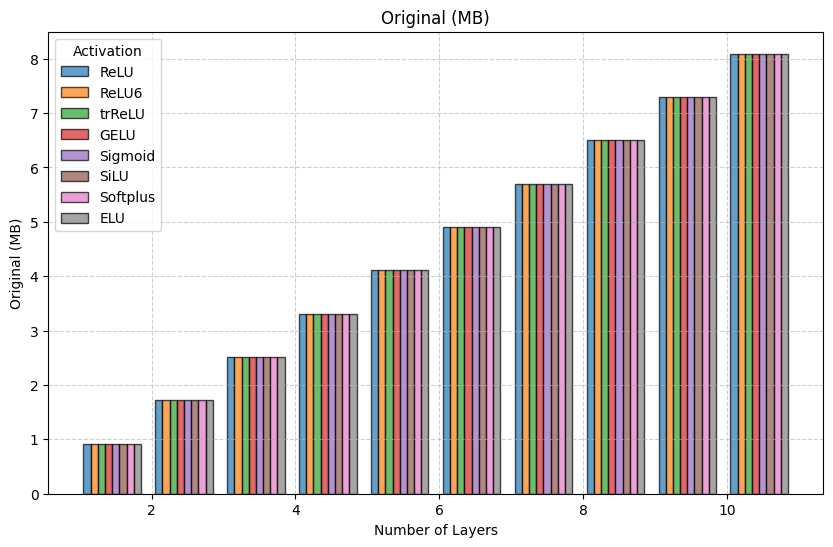

In [180]:
plot_feature_all_activations(combine_with_activations_statistic,'Original (MB)',activations='all',plottype='bar')

In [181]:
for i in range(10):
    print(df_size_relu['Original (MB)'].round(2)[i],'&')

0.92 &
1.72 &
2.51 &
3.31 &
4.11 &
4.9 &
5.7 &
6.5 &
7.29 &
8.09 &


## [Size of models] Print the LaTex Table

In [182]:
print(df_size_relu.to_latex(index=False,caption="PPI. Model sizes before and after Post-Training Quantization (PTQ).",
    label="tab:ppi:changes_of_size"))

\begin{table}
\caption{PPI. Model sizes before and after Post-Training Quantization (PTQ).}
\label{tab:ppi:changes_of_size}
\begin{tabular}{rrrrr}
\toprule
Layers & Original (MB) & Quantized (MB) & Delta & Reduction(%) \\
\midrule
1 & 0.922108 & 0.242060 & 0.680048 & -73.700000 \\
2 & 1.718266 & 0.450790 & 1.267476 & -73.800000 \\
3 & 2.514808 & 0.659584 & 1.855224 & -73.800000 \\
4 & 3.311350 & 0.868378 & 2.442972 & -73.800000 \\
5 & 4.107892 & 1.077172 & 3.030720 & -73.800000 \\
6 & 4.904370 & 1.285972 & 3.618398 & -73.800000 \\
7 & 5.700912 & 1.494783 & 4.206129 & -73.800000 \\
8 & 6.497390 & 1.703594 & 4.793796 & -73.800000 \\
9 & 7.293933 & 1.912405 & 5.381528 & -73.800000 \\
10 & 8.090486 & 2.121216 & 5.969270 & -73.800000 \\
\bottomrule
\end{tabular}
\end{table}



# [Analysis] Elapsed time

## [Elapsed time] Read the data

In [183]:
file="_results_time_for_appendix.csv"
df_time_relu=pd.read_csv(f'{file_path}/acrgnn_relu/ppi_relu{file}')
df_time_relu6=pd.read_csv(f'{file_path}/acrgnn_relu6/ppi_relu6{file}')
df_time_trrelu=pd.read_csv(f'{file_path}/acrgnn_trrelu/ppi_trrelu{file}')
df_time_gelu=pd.read_csv(f'{file_path}/acrgnn_gelu/ppi_gelu{file}')
df_time_sigmoid=pd.read_csv(f'{file_path}/acrgnn_sigmoid/ppi_sigmoid{file}')
df_time_silu=pd.read_csv(f'{file_path}/acrgnn_silu/ppi_silu{file}')
df_time_softplus=pd.read_csv(f'{file_path}/acrgnn_softplus/ppi_softplus{file}')
df_time_elu=pd.read_csv(f'{file_path}/acrgnn_elu/ppi_elu{file}')

In [184]:
df_time_relu.head()

,Layers,Elapsed_Time_Train,Elapsed_Time_Train_dPTQ,Elapsed_Time_Test,Elapsed_Time_Test_dPTQ,Elapsed_Time_Val,Elapsed_Time_Val_dPTQ
0,1,0.782194,0.709,0.101669,0.108,0.100250,0.091
1,2,0.982633,0.966,0.138278,0.154,0.142126,0.128
2,3,1.140966,1.183,0.166038,0.153,0.188262,0.165
3,4,1.381747,1.499,0.198892,0.190,0.213632,0.225
4,5,1.630077,1.714,0.193686,0.182,0.230153,0.239


## [Elapsed time] Collect the data and form one dataset

In [185]:
def combine_with_activation_elapsed_time(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[["Layers", "activation_function", 'Elapsed_Time_Train'	,'Elapsed_Time_Train_dPTQ',	'Elapsed_Time_Test',	'Elapsed_Time_Test_dPTQ'	,'Elapsed_Time_Val',	'Elapsed_Time_Val_dPTQ']])
    return pd.concat(combined, ignore_index=True)

In [186]:
combine_with_activation_elapsed_time_ppi = combine_with_activation_elapsed_time(
    [df_time_relu,df_time_relu6,df_time_trrelu, df_time_gelu,df_time_sigmoid,df_time_silu,df_time_softplus,df_time_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"])

combine_with_activation_elapsed_time_ppi.head()

,Layers,activation_function,Elapsed_Time_Train,Elapsed_Time_Train_dPTQ,Elapsed_Time_Test,Elapsed_Time_Test_dPTQ,Elapsed_Time_Val,Elapsed_Time_Val_dPTQ
0,1,ReLU,0.782194,0.709,0.101669,0.108,0.100250,0.091
1,2,ReLU,0.982633,0.966,0.138278,0.154,0.142126,0.128
2,3,ReLU,1.140966,1.183,0.166038,0.153,0.188262,0.165
3,4,ReLU,1.381747,1.499,0.198892,0.190,0.213632,0.225
4,5,ReLU,1.630077,1.714,0.193686,0.182,0.230153,0.239


## [Elapsed time] Form LaTex Table

In [187]:
col = [
    'Elapsed_Time_Train', 'Elapsed_Time_Train_dPTQ',
    'Elapsed_Time_Test', 'Elapsed_Time_Test_dPTQ',
    'Elapsed_Time_Val', 'Elapsed_Time_Val_dPTQ'
]

activation_order = ["ReLU", "ReLU6", "trReLU", "GELU", "Sigmoid", "SiLU", "Softplus", "ELU"]


df_elapsed_time = combine_with_activation_elapsed_time_ppi.groupby(
    ["activation_function"], as_index=False
)[col].sum()


df_elapsed_time["activation_function"] = pd.Categorical(
    df_elapsed_time["activation_function"], activation_order, ordered=True
)


df_elapsed_time = df_elapsed_time.sort_values("activation_function")
df_elapsed_time.head()

latex = df_elapsed_time.to_latex(
    index=False,
    header=True,
    float_format="%.2f",
    caption="Total Elapsed time (s) per activation function and datasets before and after applying dPTQ",
    label="tab:ppi:elapsedtime",
    column_format="l" + "r"*len(activation_order)   # one "l" for row labels + "r" per column
)

print(latex)

\begin{table}
\caption{Total Elapsed time (s) per activation function and datasets before and after applying dPTQ}
\label{tab:ppi:elapsedtime}
\begin{tabular}{lrrrrrrrr}
\toprule
activation_function & Elapsed_Time_Train & Elapsed_Time_Train_dPTQ & Elapsed_Time_Test & Elapsed_Time_Test_dPTQ & Elapsed_Time_Val & Elapsed_Time_Val_dPTQ \\
\midrule
ReLU & 22.46 & 23.13 & 2.56 & 2.57 & 3.04 & 3.02 \\
ReLU6 & 21.18 & 22.44 & 2.54 & 2.69 & 2.90 & 3.17 \\
trReLU & 19.93 & 20.61 & 2.50 & 2.51 & 2.89 & 3.00 \\
GELU & 23.89 & 25.37 & 2.82 & 2.91 & 3.40 & 3.25 \\
Sigmoid & 22.52 & 24.53 & 2.72 & 2.85 & 3.17 & 3.24 \\
SiLU & 23.14 & 24.06 & 2.72 & 2.87 & 3.51 & 3.16 \\
Softplus & 21.65 & 24.97 & 2.76 & 3.04 & 3.27 & 3.23 \\
ELU & 26.13 & 26.05 & 3.31 & 3.22 & 3.90 & 3.52 \\
\bottomrule
\end{tabular}
\end{table}



## [Elapsed time] Calculate the Speedup

Mean dPTQ speedup (non‑dPTQ time / dPTQ time)

In [188]:
def prepare_speedup_df(
    dataframe: pd.DataFrame,
    time_col_non,
    time_col_ptq,
):
    
    """
      - speedup = time_non / time_ptq
      - delta_time = time_non - time_ptq
      - delta_pct = 100 * (time_non - time_ptq) / time_non
    """
    df=dataframe.copy()
    if len(time_col_non) == len(time_col_ptq):
        for i in range(len(time_col_non)):
            df[f"speedup_{time_col_non[i].split('_')[2]}"]   = df[time_col_non[i]] / df[time_col_ptq[i]]
            df[f"delta_time_{time_col_non[i].split('_')[2]}"] = df[time_col_non[i]]  - df[time_col_ptq[i]]
            df[f"delta_pct_{time_col_non[i].split('_')[2]}"] = 100.0 * df[f"delta_time_{time_col_non[i].split('_')[2]}"] / df[time_col_non[i]] 
    return df.drop(columns=time_col_non).drop(columns=time_col_ptq)

In [189]:
speed=prepare_speedup_df(combine_with_activation_elapsed_time_ppi,time_col_non=["Elapsed_Time_Train",'Elapsed_Time_Test','Elapsed_Time_Val'], time_col_ptq=["Elapsed_Time_Train_dPTQ",'Elapsed_Time_Test_dPTQ','Elapsed_Time_Val_dPTQ'])
speed.head()

,Layers,activation_function,speedup_Train,delta_time_Train,delta_pct_Train,speedup_Test,delta_time_Test,delta_pct_Test,speedup_Val,delta_time_Val,delta_pct_Val
0,1,ReLU,1.103236,0.073194,9.357569,0.941383,-0.006331,-6.226745,1.101648,0.009250,9.226938
1,2,ReLU,1.017218,0.016633,1.692685,0.897912,-0.015722,-11.369459,1.110356,0.014126,9.938819
2,3,ReLU,0.964468,-0.042034,-3.684077,1.085214,0.013038,7.852307,1.140979,0.023262,12.355956
3,4,ReLU,0.921779,-0.117253,-8.485888,1.046798,0.008892,4.470595,0.949474,-0.011368,-5.321483
4,5,ReLU,0.951037,-0.083923,-5.148399,1.064206,0.011686,6.033250,0.962983,-0.008847,-3.844034


In [190]:
def speedup_summary(speed_df: pd.DataFrame):
    # Mean speedup across layers, per activation & key
    by_act_dataset = speed.groupby(["activation_function"], as_index=False).agg(
    mean_speedup_Train=("speedup_Train", "mean"),
    mean_speedup_Test=("speedup_Test", "mean"),
    mean_speedup_Val=("speedup_Val", "mean")
    )
    
    activation_order = ["ReLU", "ReLU6", "trReLU", "GELU", "Sigmoid", "SiLU", "Softplus", "ELU"]
    
    by_act_dataset["activation_function"] = pd.Categorical(
        by_act_dataset["activation_function"],
        categories=activation_order,
        ordered=True
    )
    
    # 🔧 Sort by the ordered categorical column
    by_act_dataset = by_act_dataset.sort_values("activation_function")

   
    return by_act_dataset

In [191]:
def plot_speedup_bar(speed_df: pd.DataFrame,
                     activation_order=("ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU")):
    by_act_dataset = speedup_summary(speed_df)
    
    # Melt the dataframe to long format
    df_long = by_act_dataset.melt(
        id_vars=["activation_function"],
        value_vars=["mean_speedup_Train", "mean_speedup_Test", "mean_speedup_Val"],
        var_name="Speedup_Type",
        value_name="Speedup"
    )

    # Clean up labels
    df_long["Speedup_Type"] = df_long["Speedup_Type"].str.replace("mean_speedup_", "", regex=False)

    # Plot
    fig = px.bar(
        df_long,
        x="activation_function",
        y="Speedup",
        color="Speedup_Type",
        barmode="group",
        category_orders={"activation_function": list(activation_order)},
        text=df_long["Speedup"].round(2).astype(str),
        labels={"activation_function": "Activation", "Speedup": "Speedup (original / dPTQ)", "Speedup_Type": "Phase"},
        title="Dynamic PTQ Speedup by Activation (mean across layers)"
    )

    fig.update_traces(textposition="outside", cliponaxis=False)
    fig.update_layout(uniformtext_minsize=10, uniformtext_mode="hide", height=500)
    return fig

## [Elapsed Time] Dynamic PTQ Speedup by Activation (mean across layers)

In [192]:
plot_speedup_bar(speed).show()

# [Analysis] Accuracy Before Quantization

## [Before Quantization] Read the data

In [193]:
file="_results_for_appendix.csv"
df_acc_original_relu=pd.read_csv(f'{file_path}/acrgnn_relu/ppi_relu{file}')
df_acc_original_relu6=pd.read_csv(f'{file_path}/acrgnn_relu6/ppi_relu6{file}')
df_acc_original_trrelu=pd.read_csv(f'{file_path}/acrgnn_trrelu/ppi_trrelu{file}')
df_acc_original_gelu=pd.read_csv(f'{file_path}/acrgnn_gelu/ppi_gelu{file}')
df_acc_original_sigmoid=pd.read_csv(f'{file_path}/acrgnn_sigmoid/ppi_sigmoid{file}')
df_acc_original_silu=pd.read_csv(f'{file_path}/acrgnn_silu/ppi_silu{file}')
df_acc_original_softplus=pd.read_csv(f'{file_path}/acrgnn_softplus/ppi_softplus{file}')
df_acc_original_elu=pd.read_csv(f'{file_path}/acrgnn_elu/ppi_elu{file}')

In [194]:
df_acc_original_relu.head()

,Layers,Train_Loss_Original,Train_Acc_Original,Elapsed_Time_Train_Original,Test_Loss_Original,Test_Acc_Original,Elapsed_Time_Test_Original,Val_Loss_Original,Val_Acc_Original,Elapsed_Time_Val_Original
0,1,0.455773,0.596249,0.782,9.087560e-01,0.477143,0.102,1.159994e+00,0.524235,0.100
1,2,0.452021,0.614906,0.983,1.709250e+03,0.370141,0.138,5.289721e+03,0.420826,0.142
2,3,0.449812,0.620675,1.141,1.861400e+07,0.347550,0.166,1.026196e+07,0.383117,0.188
3,4,0.454635,0.621662,1.382,5.088825e+10,0.349139,0.199,4.512186e+10,0.350034,0.214
4,5,0.450536,0.617844,1.630,1.204489e+11,0.433776,0.194,2.066614e+11,0.429043,0.230


## [Before Quantization] Combine activation functions to form one table

In [195]:
def combine_with_activation_accuracy(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[['Layers','activation_function','Train_Acc_Original','Test_Acc_Original','Val_Acc_Original']])
    return pd.concat(combined, ignore_index=True)


In [196]:
combine_with_activation_accuracy_original = combine_with_activation_accuracy(
    [df_acc_original_relu,df_acc_original_relu6,df_acc_original_trrelu, df_acc_original_gelu,df_acc_original_sigmoid,df_acc_original_silu,df_acc_original_softplus,df_acc_original_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
)
combine_with_activation_accuracy_original.head()


,Layers,activation_function,Train_Acc_Original,Test_Acc_Original,Val_Acc_Original
0,1,ReLU,0.596249,0.477143,0.524235
1,2,ReLU,0.614906,0.370141,0.420826
2,3,ReLU,0.620675,0.347550,0.383117
3,4,ReLU,0.621662,0.349139,0.350034
4,5,ReLU,0.617844,0.433776,0.429043


In [197]:
combine_with_activation_accuracy_original=combine_with_activation_accuracy_original.rename(columns={"Train_Acc_Original": "Train_Acc", "Test_Acc_Original": "Test_Acc","Val_Acc_Original": "Val_Acc"})

## [Before Quantization] Boxplot across depth for each activation function

In [198]:
def boxplots_key_with_metrics(
    df: pd.DataFrame,
    metrics=('Train_Acc','Test_Acc','Val_Acc'),
    activation_order=("ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU"),
    percent=True,
    title=None
):
    # filter for one key
    use = df.copy()
    use["activation_function"] = pd.Categorical(
        use["activation_function"], activation_order, ordered=True
    )

    # melt into long format
    long = use.melt(
        id_vars=["activation_function","Layers"],
        value_vars=list(metrics),
        var_name="metric",
        value_name="value"
    )
    if percent:
        long["value"] = long["value"] * 100

    fig = px.box(
        long,
        x="activation_function",
        y="value",
        color="metric",   # ✅ train/test1/test2 as colors
        category_orders={"activation_function": list(activation_order)},
        points="all",     # show all layer results
        title=title or f"Accuracy of the ACR-GNN grouped by activation across the depth"
    )
    fig.update_xaxes(title="Activation Function")
    fig.update_yaxes(title=("Accuracy (%)" if percent else "Accuracy"))
    fig.update_layout(boxmode="group")  # group train/test1/test2 side by side
    return fig

In [199]:
boxplots_key_with_metrics(combine_with_activation_accuracy_original).show()

## [Before Quantization] Heatmap of the accuracy across activation functions and depth

In [200]:
def heatmap_grid(df: pd.DataFrame, name,
                 metrics=('Train_Acc','Test_Acc','Val_Acc'),
                 activation_order=("ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU"),
                 percent=True):
    # Make subplot grid: rows = metrics, cols = keys
    fig = make_subplots(
        rows=len(metrics), cols=1,
        subplot_titles=[f"{m.split('_')[0].capitalize()}" for m in metrics ],
        horizontal_spacing=0.05, vertical_spacing=0.08
    )

    # Ensure consistent order for activations
    df = df.copy()
    df["activation_function"] = pd.Categorical(df["activation_function"], activation_order, ordered=True)

    # Iterate over metrics and keys
    for i, m in enumerate(metrics, start=1):
        
            
        z = df.pivot(index="Layers", columns="activation_function", values=m).sort_index()
        if percent:
            z = z * 100

        heatmap = go.Heatmap(
            z=z.values,
            x=z.columns.astype(str),
            y=z.index.astype(str),
            coloraxis="coloraxis",
            hovertemplate=f"Layer: %{{y}}<br>Activation: %{{x}}<br>{m}: %{{z:.2f}}<extra></extra>"
        )
        fig.add_trace(heatmap, row=i, col=1)
    if name == 'nonqua':
        name_title = "ACR-GNN Accuracy Heatmaps (Layers × Activations)"
    elif name == 'dPTQ':
        name_title= "ACR-GNN after dPTQ Accuracy Heatmaps (Layers × Activations)"
    elif name == 'diff':
        name_title= "Accuracy Difference Heatmaps for ACR-GNN after dPTQ(Layers × Activations)"
    
    # Shared color scale
    fig.update_layout(
        title=name_title,
        coloraxis=dict(colorscale="Viridis", colorbar=dict(title="Accuracy (%)"))
    )

    return fig

In [201]:
heatmap_grid(combine_with_activation_accuracy_original,name='nonqua').show()

## [Before Quantization] LaTex tables "Accuracy of the #-layer ACR-GNN with different activation functions (A/F)."

In [202]:
def print_latex_table_of_acc_ppi(DataFrame,cols,name):
    for numero_l in range(1,11):
        df_percent = DataFrame[(DataFrame['Layers']==numero_l) ].drop(columns=['Layers'])
        df_percent[cols] = df_percent[cols].mul(100).round(1)  # % format
        
        activation_order = ["ReLU", "ReLU6", "trReLU", "GELU", "Sigmoid", "SiLU", "Softplus", "ELU"]
        
        # Make 'activation_function' a categorical column with this order
        df_percent["activation_function"] = pd.Categorical(
            df_percent["activation_function"],
            categories=activation_order,
            ordered=True
        )
        
        # Sort according to the defined order
        df_percent = df_percent.sort_values("activation_function")
        
        
        
        # Pivot so that activation_function is index and keys become columns
        table_df = df_percent
        if name == 'nonqua':
            name_label='nonqua'
            name_caption='.'
        elif name== 'dPTQ':
            name_label='dptq'
            name_caption= ' after dPTQ.'
        # Convert to LaTeX
        latex_str = table_df.to_latex(
            index=False,
            header=True,
            multicolumn=True,
            multirow=False,
            escape=False,
            column_format="c ccc ccc ccc",
            caption=f"Accuracy of the {numero_l}-layer ACR-GNN with different activation functions (A/F){name_caption}",
            label=f"tab:ppi:{name_label}:ACR-GNN:{numero_l}layer",
            float_format="%.1f\\%%"  # formats numbers like 96.9%
        )
        print('-------',numero_l)
        print(latex_str)

In [203]:
 cols = ['Train_Acc','Test_Acc','Val_Acc']
 print_latex_table_of_acc_ppi(combine_with_activation_accuracy_original,cols,name='nonqua')

------- 1
\begin{table}
\caption{Accuracy of the 1-layer ACR-GNN with different activation functions (A/F).}
\label{tab:ppi:nonqua:ACR-GNN:1layer}
\begin{tabular}{c ccc ccc ccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc \\
\midrule
ReLU & 59.6\% & 47.7\% & 52.4\% \\
ReLU6 & 54.2\% & 46.4\% & 50.9\% \\
trReLU & 52.0\% & 38.3\% & 37.9\% \\
GELU & 58.1\% & 41.9\% & 49.6\% \\
Sigmoid & 51.1\% & 41.0\% & 38.6\% \\
SiLU & 58.7\% & 44.0\% & 49.6\% \\
Softplus & 58.7\% & 42.2\% & 49.2\% \\
ELU & 55.3\% & 41.5\% & 43.7\% \\
\bottomrule
\end{tabular}
\end{table}

------- 2
\begin{table}
\caption{Accuracy of the 2-layer ACR-GNN with different activation functions (A/F).}
\label{tab:ppi:nonqua:ACR-GNN:2layer}
\begin{tabular}{c ccc ccc ccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc \\
\midrule
ReLU & 61.5\% & 37.0\% & 42.1\% \\
ReLU6 & 54.2\% & 38.6\% & 35.3\% \\
trReLU & 51.6\% & 35.6\% & 35.6\% \\
GELU & 61.4\% & 42.7\% & 45.1\% \\
Sigmoid & 51.7\% & 38.7\%

## [Before Quantization] Generalization Ratio and Gap

We can compute the generalization ratio of the models to measure how well the model generalizes beyond training data. 
\begin{equation*}
    \text{Generalization Ratio}= \frac{\text{Train Accuracy}}{\text{Test Accuracy}}
\end{equation*}
If the ratio is close to 1, the model generalizes well (Test $\approx$ Train). If it is much less than 1, the model is overfitting (Train $\gg$ Test). In our case, we compute it separately for Test1 and Test2.

In [204]:
combine_with_activation_accuracy_original.head()

,Layers,activation_function,Train_Acc,Test_Acc,Val_Acc
0,1,ReLU,0.596249,0.477143,0.524235
1,2,ReLU,0.614906,0.370141,0.420826
2,3,ReLU,0.620675,0.347550,0.383117
3,4,ReLU,0.621662,0.349139,0.350034
4,5,ReLU,0.617844,0.433776,0.429043


In [205]:
def calculateGG_and_GP(dataframe):
    df_generalization_ratio_original = dataframe
    
    df_generalization_ratio_original['GR_Test1']=df_generalization_ratio_original['Test_Acc']/df_generalization_ratio_original['Train_Acc']
    df_generalization_ratio_original['GGap_Test1']=df_generalization_ratio_original['Train_Acc']-df_generalization_ratio_original['Test_Acc']
    
    df_generalization_ratio_original['GR_Test2']=df_generalization_ratio_original['Val_Acc']/df_generalization_ratio_original['Train_Acc']
    df_generalization_ratio_original['GGap_Test2']=df_generalization_ratio_original['Train_Acc']-df_generalization_ratio_original['Val_Acc']
    
    
    df_generalization_ratio_original=df_generalization_ratio_original.drop(columns=['Train_Acc','Test_Acc','Val_Acc'])
    return dataframe

## [Before Quantization] LaTex tables "Generalization performance of the #-layer ACR-GNN with different activation functions (A/F), reported as both Generalization Ratios (Test/Train) and Generalization Gaps (Train – Test accuracy)."

In [206]:
def print_latex_table_of_GGGP_ppi(DataFrame,cols,name):
    activation_order = ["ReLU", "ReLU6", "trReLU", "GELU", "Sigmoid", "SiLU", "Softplus", "ELU"]
    for numero_l in range(1,11):
        df_percent=DataFrame[(DataFrame['Layers']==numero_l) ].drop(columns=['Layers'])
        # Make 'activation_function' a categorical column with this order
        df_percent["activation_function"] = pd.Categorical(
            df_percent["activation_function"],
            categories=activation_order,
            ordered=True
        )
        
        # Sort according to the defined order
        df_percent = df_percent.sort_values("activation_function")
        
        
        
        # Pivot so that activation_function is index and keys become columns
        table_df = df_percent
        if name == 'nonqua':
            name_label='nonqua'
            name_caption='.'
        elif name== 'dPTQ':
            name_label='dptq'
            name_caption= ' after dPTQ.'
        
        # Convert to LaTeX
        latex_str = table_df.to_latex(
            index=False,
            header=True,
            multicolumn=True,
            multirow=False,
            escape=False,
            column_format="ccccc",
            caption=f"Generalization performance of the {numero_l}-layer ACR-GNN with different activation functions (A/F), reported as both Generalization Ratios (Test/Train) and Generalization Gaps (Train – Test accuracy){name_caption}",
            label=f"tab:ppi:{name_label}:generalizationperformance:ACR-GNN:{numero_l}layer",
            float_format="%.3f"  # formats numbers like 96.9%
        )
        print('-------',numero_l)
        print(latex_str)


In [207]:
cols = ["GR_Test1", "GGap_Test1", "GR_Test2","GGap_Test2"]
print_latex_table_of_GGGP_ppi(calculateGG_and_GP(combine_with_activation_accuracy_original),cols,name='nonqua')

------- 1
\begin{table}
\caption{Generalization performance of the 1-layer ACR-GNN with different activation functions (A/F), reported as both Generalization Ratios (Test/Train) and Generalization Gaps (Train – Test accuracy).}
\label{tab:ppi:nonqua:generalizationperformance:ACR-GNN:1layer}
\begin{tabular}{ccccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc & GR_Test1 & GGap_Test1 & GR_Test2 & GGap_Test2 \\
\midrule
ReLU & 0.596 & 0.477 & 0.524 & 0.800 & 0.119 & 0.879 & 0.072 \\
ReLU6 & 0.542 & 0.464 & 0.509 & 0.857 & 0.078 & 0.938 & 0.033 \\
trReLU & 0.520 & 0.383 & 0.379 & 0.737 & 0.137 & 0.728 & 0.141 \\
GELU & 0.581 & 0.419 & 0.496 & 0.721 & 0.162 & 0.854 & 0.085 \\
Sigmoid & 0.511 & 0.410 & 0.386 & 0.803 & 0.101 & 0.756 & 0.125 \\
SiLU & 0.587 & 0.440 & 0.496 & 0.750 & 0.147 & 0.845 & 0.091 \\
Softplus & 0.587 & 0.422 & 0.492 & 0.718 & 0.166 & 0.837 & 0.096 \\
ELU & 0.553 & 0.415 & 0.437 & 0.750 & 0.138 & 0.791 & 0.116 \\
\bottomrule
\end{tabular}
\end{table}

---

# [Analysis] Accuracy after dPTQ

## [dPTQ] Read the data

In [208]:
file="_quantized_results_for_appendix.csv"
df_acc_dptq_relu=pd.read_csv(f'{file_path}/acrgnn_relu/ppi_relu{file}')
df_acc_dptq_relu6=pd.read_csv(f'{file_path}/acrgnn_relu6/ppi_relu6{file}')
df_acc_dptq_trrelu=pd.read_csv(f'{file_path}/acrgnn_trrelu/ppi_trrelu{file}')
df_acc_dptq_gelu=pd.read_csv(f'{file_path}/acrgnn_gelu/ppi_gelu{file}')
df_acc_dptq_sigmoid=pd.read_csv(f'{file_path}/acrgnn_sigmoid/ppi_sigmoid{file}')
df_acc_dptq_silu=pd.read_csv(f'{file_path}/acrgnn_silu/ppi_silu{file}')
df_acc_dptq_softplus=pd.read_csv(f'{file_path}/acrgnn_softplus/ppi_softplus{file}')
df_acc_dptq_elu=pd.read_csv(f'{file_path}/acrgnn_elu/ppi_elu{file}')

In [209]:
df_acc_dptq_relu.head()

,Layers,Train_Loss_quantized,Train_Acc_quantized,Elapsed_Time_Train_quantized,Test_Loss_quantized,Test_Acc_quantized,Elapsed_Time_Test_quantized,Val_Loss_quantized,Val_Acc_quantized,Elapsed_Time_Val_quantized
0,1,0.462074,0.603570,0.709,9.742991e-01,0.495260,0.108,1.350592e+00,0.522956,0.091
1,2,0.454233,0.611809,0.966,1.952038e+03,0.370992,0.154,7.566718e+03,0.389621,0.128
2,3,0.452970,0.614842,1.183,3.669444e+06,0.353863,0.153,4.186936e+06,0.386753,0.165
3,4,0.458461,0.616516,1.499,4.606471e+10,0.347858,0.190,3.914008e+10,0.351602,0.225
4,5,0.456002,0.611413,1.714,1.402422e+11,0.431165,0.182,2.620005e+11,0.411415,0.239


## [dPTQ] Slice only Accuracy columns

In [210]:
columns=['Layers','Train_Acc_quantized','Test_Acc_quantized','Val_Acc_quantized']
df_acc_dptq_relu[columns].head()

,Layers,Train_Acc_quantized,Test_Acc_quantized,Val_Acc_quantized
0,1,0.603570,0.495260,0.522956
1,2,0.611809,0.370992,0.389621
2,3,0.614842,0.353863,0.386753
3,4,0.616516,0.347858,0.351602
4,5,0.611413,0.431165,0.411415


## [dPTQ] Combine activation functions to form one table

In [211]:
def combine_with_activation_accuracy_dptq(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[['Layers','activation_function','Train_Acc_quantized','Test_Acc_quantized','Val_Acc_quantized']])
    return pd.concat(combined, ignore_index=True)

In [212]:
combine_with_activation_accuracy_dptq = combine_with_activation_accuracy_dptq(
    [df_acc_dptq_relu,df_acc_dptq_relu6,df_acc_dptq_trrelu, df_acc_dptq_gelu,df_acc_dptq_sigmoid,df_acc_dptq_silu,df_acc_dptq_softplus,df_acc_dptq_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
)
combine_with_activation_accuracy_dptq.head()

,Layers,activation_function,Train_Acc_quantized,Test_Acc_quantized,Val_Acc_quantized
0,1,ReLU,0.603570,0.495260,0.522956
1,2,ReLU,0.611809,0.370992,0.389621
2,3,ReLU,0.614842,0.353863,0.386753
3,4,ReLU,0.616516,0.347858,0.351602
4,5,ReLU,0.611413,0.431165,0.411415


In [213]:
combine_with_activation_accuracy_dptq=combine_with_activation_accuracy_dptq.rename(columns={"Train_Acc_quantized": "Train_Acc", "Test_Acc_quantized": "Test_Acc","Val_Acc_quantized": "Val_Acc"})

## [dPTQ] Boxplot across depth for each activation function

In [214]:
boxplots_key_with_metrics(combine_with_activation_accuracy_dptq).show()

## [dPTQ] Heatmap of the accuracy across activation functions and depth

In [215]:
heatmap_grid(combine_with_activation_accuracy_dptq,name='dPTQ').show()

In [216]:
 cols = ['Train_Acc','Test_Acc','Val_Acc']
 print_latex_table_of_acc_ppi(combine_with_activation_accuracy_dptq,cols,name='dPTQ')

------- 1
\begin{table}
\caption{Accuracy of the 1-layer ACR-GNN with different activation functions (A/F) after dPTQ.}
\label{tab:ppi:dptq:ACR-GNN:1layer}
\begin{tabular}{c ccc ccc ccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc \\
\midrule
ReLU & 60.4\% & 49.5\% & 52.3\% \\
ReLU6 & 54.8\% & 45.8\% & 50.3\% \\
trReLU & 52.4\% & 38.2\% & 37.8\% \\
GELU & 59.2\% & 42.4\% & 50.2\% \\
Sigmoid & 52.2\% & 41.3\% & 38.7\% \\
SiLU & 58.8\% & 45.0\% & 50.2\% \\
Softplus & 59.3\% & 39.6\% & 47.6\% \\
ELU & 55.6\% & 40.0\% & 43.0\% \\
\bottomrule
\end{tabular}
\end{table}

------- 2
\begin{table}
\caption{Accuracy of the 2-layer ACR-GNN with different activation functions (A/F) after dPTQ.}
\label{tab:ppi:dptq:ACR-GNN:2layer}
\begin{tabular}{c ccc ccc ccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc \\
\midrule
ReLU & 61.2\% & 37.1\% & 39.0\% \\
ReLU6 & 54.2\% & 38.1\% & 36.2\% \\
trReLU & 51.4\% & 35.7\% & 35.4\% \\
GELU & 61.1\% & 41.7\% & 44.2\% \\
Sigmoid

In [217]:
cols = ["GR_Test1", "GGap_Test1", "GR_Test2","GGap_Test2"]
print_latex_table_of_GGGP_ppi(calculateGG_and_GP(combine_with_activation_accuracy_dptq),cols,name='dPTQ')

------- 1
\begin{table}
\caption{Generalization performance of the 1-layer ACR-GNN with different activation functions (A/F), reported as both Generalization Ratios (Test/Train) and Generalization Gaps (Train – Test accuracy) after dPTQ.}
\label{tab:ppi:dptq:generalizationperformance:ACR-GNN:1layer}
\begin{tabular}{ccccc}
\toprule
activation_function & Train_Acc & Test_Acc & Val_Acc & GR_Test1 & GGap_Test1 & GR_Test2 & GGap_Test2 \\
\midrule
ReLU & 0.604 & 0.495 & 0.523 & 0.821 & 0.108 & 0.866 & 0.081 \\
ReLU6 & 0.548 & 0.458 & 0.503 & 0.835 & 0.090 & 0.917 & 0.045 \\
trReLU & 0.524 & 0.382 & 0.378 & 0.728 & 0.143 & 0.722 & 0.146 \\
GELU & 0.592 & 0.424 & 0.502 & 0.716 & 0.168 & 0.848 & 0.090 \\
Sigmoid & 0.522 & 0.413 & 0.387 & 0.791 & 0.109 & 0.741 & 0.135 \\
SiLU & 0.588 & 0.450 & 0.502 & 0.765 & 0.138 & 0.854 & 0.086 \\
Softplus & 0.593 & 0.396 & 0.476 & 0.667 & 0.197 & 0.802 & 0.118 \\
ELU & 0.556 & 0.400 & 0.430 & 0.719 & 0.156 & 0.774 & 0.125 \\
\bottomrule
\end{tabular}
\end{ta

# [Analysis] Difference between Before and After dynamic Post-Training Quantization

## [Difference] Combine data before and after dPTQ

In [218]:
cols_to_compare = ["Train_Acc", "Test_Acc", "Val_Acc"]

# Align DataFrames by index (to make sure subtraction is valid)
df1 = combine_with_activation_accuracy_original.set_index(["activation_function", "Layers"])
df2 = combine_with_activation_accuracy_dptq.set_index(["activation_function", "Layers"])

# Calculate differences only for selected columns
df_diff = df1[cols_to_compare] - df2[cols_to_compare]

# Reset index if needed
df_diff = df_diff.reset_index()

df_diff.head()

,activation_function,Layers,Train_Acc,Test_Acc,Val_Acc
0,ReLU,1,-0.007321,-0.018117,0.001279
1,ReLU,2,0.003097,-0.000851,0.031206
2,ReLU,3,0.005832,-0.006313,-0.003637
3,ReLU,4,0.005146,0.001281,-0.001567
4,ReLU,5,0.006432,0.002611,0.017629


## [Difference] Boxplot across depth for each activation function

In [219]:
boxplots_key_with_metrics(df_diff).show()

## [Difference] Heatmap across depth for each activation function

In [220]:
heatmap_grid(df_diff,name='diff').show()

## [Difference] Calculate the Running Time of all models before and after dPTQ

In [221]:
def combine_with_activation_elapsed_time(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[['Layers','activation_function','Elapsed_Time_Train_Original','Elapsed_Time_Test_Original','Elapsed_Time_Val_Original']])
    return pd.concat(combined, ignore_index=True)

In [222]:
combine_with_activation_elapsed_time_dataframe = combine_with_activation_elapsed_time(
    [df_acc_original_relu,df_acc_original_relu6,df_acc_original_trrelu, df_acc_original_gelu,df_acc_original_sigmoid,df_acc_original_silu,df_acc_original_softplus,df_acc_original_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
)
combine_with_activation_elapsed_time_dataframe.head()


,Layers,activation_function,Elapsed_Time_Train_Original,Elapsed_Time_Test_Original,Elapsed_Time_Val_Original
0,1,ReLU,0.782,0.102,0.100
1,2,ReLU,0.983,0.138,0.142
2,3,ReLU,1.141,0.166,0.188
3,4,ReLU,1.382,0.199,0.214
4,5,ReLU,1.630,0.194,0.230


In [223]:
def combine_with_activation_elapsed_time_dptq(dataframes, activations):
    combined = []
    for df, act in zip(dataframes, activations):
        temp = df.copy()
        temp["activation_function"] = act
        combined.append(temp[['Layers','activation_function','Elapsed_Time_Train_quantized','Elapsed_Time_Test_quantized','Elapsed_Time_Val_quantized']])
    return pd.concat(combined, ignore_index=True)

In [224]:
combine_with_activation_elapsed_time_dptq_dataframe = combine_with_activation_elapsed_time_dptq(
    [df_acc_dptq_relu,df_acc_dptq_relu6,df_acc_dptq_trrelu, df_acc_dptq_gelu,df_acc_dptq_sigmoid,df_acc_dptq_silu,df_acc_dptq_softplus,df_acc_dptq_elu],
    ["ReLU","ReLU6","trReLU", "GELU","Sigmoid","SiLU","Softplus","ELU"]
)
combine_with_activation_elapsed_time_dptq_dataframe.head()

,Layers,activation_function,Elapsed_Time_Train_quantized,Elapsed_Time_Test_quantized,Elapsed_Time_Val_quantized
0,1,ReLU,0.709,0.108,0.091
1,2,ReLU,0.966,0.154,0.128
2,3,ReLU,1.183,0.153,0.165
3,4,ReLU,1.499,0.190,0.225
4,5,ReLU,1.714,0.182,0.239


In [225]:
dataframe_elapsed_time=pd.concat([combine_with_activation_elapsed_time_dataframe, combine_with_activation_elapsed_time_dptq_dataframe.drop(columns=['Layers','activation_function'])], axis=1)
dataframe_elapsed_time.head()

,Layers,activation_function,Elapsed_Time_Train_Original,Elapsed_Time_Test_Original,Elapsed_Time_Val_Original,Elapsed_Time_Train_quantized,Elapsed_Time_Test_quantized,Elapsed_Time_Val_quantized
0,1,ReLU,0.782,0.102,0.100,0.709,0.108,0.091
1,2,ReLU,0.983,0.138,0.142,0.966,0.154,0.128
2,3,ReLU,1.141,0.166,0.188,1.183,0.153,0.165
3,4,ReLU,1.382,0.199,0.214,1.499,0.190,0.225
4,5,ReLU,1.630,0.194,0.230,1.714,0.182,0.239


In [226]:
dataframe_elapsed_time.columns

Index(['Layers', 'activation_function', 'Elapsed_Time_Train_Original',
       'Elapsed_Time_Test_Original', 'Elapsed_Time_Val_Original',
       'Elapsed_Time_Train_quantized', 'Elapsed_Time_Test_quantized',
       'Elapsed_Time_Val_quantized'],
      dtype='object')

In [227]:
# Choose which time to report
TIME_COL = ['Elapsed_Time_Train_Original',
       'Elapsed_Time_Test_Original', 'Elapsed_Time_Val_Original',
       'Elapsed_Time_Train_quantized', 'Elapsed_Time_Test_quantized',
       'Elapsed_Time_Val_quantized']

# Desired display order
act_order = ["ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU"]
time_order = [ 'activation_function',
              'Elapsed_Time_Train_Original','Elapsed_Time_Train_quantized',
       'Elapsed_Time_Test_Original', 'Elapsed_Time_Test_quantized',
       'Elapsed_Time_Val_Original','Elapsed_Time_Val_quantized']

# 1) Sum over layers for each (key, activation)
summed = (dataframe_elapsed_time
          .groupby(["activation_function"], as_index=False)[TIME_COL]
          .sum())

# 2) Pivot into wide format
summed["activation_function"] = pd.Categorical(
    summed["activation_function"], categories=act_order, ordered=True
)
summed = summed.sort_values("activation_function")

summed = summed.loc[:,time_order] 

# 3) Export LaTeX in booktabs style
latex = summed.to_latex(
    index=False,
    header=True,
    float_format="%.2f",
    caption="Running time (s) per classifier and activation function. Total running time for the model before (o) and after dPTQ (q) in seconds across the layers.",
    label="tab:training-time",
    column_format="l" + "r"*len(act_order)   # one "l" for row labels + "r" per column
)

print(latex)


\begin{table}
\caption{Running time (s) per classifier and activation function. Total running time for the model before (o) and after dPTQ (q) in seconds across the layers.}
\label{tab:training-time}
\begin{tabular}{lrrrrrrrr}
\toprule
activation_function & Elapsed_Time_Train_Original & Elapsed_Time_Train_quantized & Elapsed_Time_Test_Original & Elapsed_Time_Test_quantized & Elapsed_Time_Val_Original & Elapsed_Time_Val_quantized \\
\midrule
ReLU & 22.46 & 23.13 & 2.56 & 2.57 & 3.04 & 3.02 \\
ReLU6 & 21.18 & 22.44 & 2.54 & 2.69 & 2.90 & 3.17 \\
trReLU & 19.93 & 20.61 & 2.50 & 2.51 & 2.89 & 3.00 \\
GELU & 23.89 & 25.37 & 2.82 & 2.91 & 3.40 & 3.25 \\
Sigmoid & 22.52 & 24.53 & 2.72 & 2.85 & 3.17 & 3.24 \\
SiLU & 23.14 & 24.06 & 2.72 & 2.87 & 3.51 & 3.16 \\
Softplus & 21.65 & 24.97 & 2.76 & 3.04 & 3.27 & 3.23 \\
ELU & 26.13 & 26.05 & 3.31 & 3.22 & 3.90 & 3.52 \\
\bottomrule
\end{tabular}
\end{table}



In [231]:
df_original_gg_gr=combine_with_activation_accuracy_original
df_original_gg_gr

,Layers,activation_function,Train_Acc,Test_Acc,Val_Acc,GR_Test1,GGap_Test1,GR_Test2,GGap_Test2
0,1,ReLU,0.596249,0.477143,0.524235,0.800241,0.119106,0.879222,0.072014
1,2,ReLU,0.614906,0.370141,0.420826,0.601947,0.244765,0.684375,0.194080
2,3,ReLU,0.620675,0.347550,0.383117,0.559956,0.273124,0.617259,0.237558
3,4,ReLU,0.621662,0.349139,0.350034,0.561622,0.272523,0.563062,0.271628
4,5,ReLU,0.617844,0.433776,0.429043,0.702080,0.184068,0.694420,0.188801
...,...,...,...,...,...,...,...,...,...
75,6,ELU,0.627444,0.388498,0.395526,0.619176,0.238946,0.630376,0.231918
76,7,ELU,0.624770,0.441852,0.449831,0.707224,0.182918,0.719994,0.174939
77,8,ELU,0.598624,0.394188,0.396420,0.658490,0.204436,0.662218,0.202204
78,9,ELU,0.608346,0.421083,0.414545,0.692177,0.187263,0.681430,0.193801


In [230]:
df_dptq_gg_gr= calculateGG_and_GP(combine_with_activation_accuracy_dptq)
df_dptq_gg_gr

,Layers,activation_function,Train_Acc,Test_Acc,Val_Acc,GR_Test1,GGap_Test1,GR_Test2,GGap_Test2
0,1,ReLU,0.603570,0.495260,0.522956,0.820551,0.108310,0.866438,0.080614
1,2,ReLU,0.611809,0.370992,0.389621,0.606385,0.240817,0.636834,0.222189
2,3,ReLU,0.614842,0.353863,0.386753,0.575535,0.260979,0.629029,0.228089
3,4,ReLU,0.616516,0.347858,0.351602,0.564232,0.268658,0.570304,0.264915
4,5,ReLU,0.611413,0.431165,0.411415,0.705196,0.180247,0.672892,0.199998
...,...,...,...,...,...,...,...,...,...
75,6,ELU,0.616027,0.384385,0.385511,0.623974,0.231642,0.625802,0.230516
76,7,ELU,0.616235,0.439284,0.451287,0.712852,0.176951,0.732330,0.164948
77,8,ELU,0.593312,0.382516,0.400645,0.644713,0.210796,0.675268,0.192667
78,9,ELU,0.603354,0.416505,0.428610,0.690316,0.186849,0.710378,0.174745


In [242]:
df_diff_gg_gr=df_dptq_gg_gr
df_diff_gg_gr['delta_accuracy_Test']=df_original_gg_gr['Test_Acc']-df_dptq_gg_gr['Test_Acc']
df_diff_gg_gr['delta_accuracy_Val']=df_original_gg_gr['Val_Acc']-df_dptq_gg_gr['Val_Acc']
order=['Layers','activation_function','GR_Test1','GGap_Test1','delta_accuracy_Test','GR_Test2','GGap_Test2','delta_accuracy_Val']
df_reordered = df_diff_gg_gr.loc[:, order]
df_reordered

,Layers,activation_function,GR_Test1,GGap_Test1,delta_accuracy_Test,GR_Test2,GGap_Test2,delta_accuracy_Val
0,1,ReLU,0.820551,0.108310,-0.018117,0.866438,0.080614,0.001279
1,2,ReLU,0.606385,0.240817,-0.000851,0.636834,0.222189,0.031206
2,3,ReLU,0.575535,0.260979,-0.006313,0.629029,0.228089,-0.003637
3,4,ReLU,0.564232,0.268658,0.001281,0.570304,0.264915,-0.001567
4,5,ReLU,0.705196,0.180247,0.002611,0.672892,0.199998,0.017629
...,...,...,...,...,...,...,...,...
75,6,ELU,0.623974,0.231642,0.004113,0.625802,0.230516,0.010015
76,7,ELU,0.712852,0.176951,0.002568,0.732330,0.164948,-0.001456
77,8,ELU,0.644713,0.210796,0.011672,0.675268,0.192667,-0.004225
78,9,ELU,0.690316,0.186849,0.004578,0.710378,0.174745,-0.014065


In [243]:
def latex_ppi_table(df, i, activation_order=None, scale=0.5,
                    caption_prefix="PPI. Layer {i}: Accuracy differences ($\\Delta_{{acc}}$, \\%) and generalization metrics (GR, $\\Delta_{{gen}}$) per activation and classifier.",
                    label_prefix="tab:dacc_gr_layer"):
    """
    Build a LaTeX table for a given layer i from a dataframe with columns:
    ['Layers','activation_function','GR_Test1','GGap_Test1','delta_accuracy_Test',
     'GR_Test2','GGap_Test2','delta_accuracy_Val']
    """

    # 1) Filter one layer
    d = df.loc[df["Layers"] == i, [
        "activation_function",
        "GR_Test1", "GGap_Test1", "delta_accuracy_Test",
        "GR_Test2", "GGap_Test2", "delta_accuracy_Val"
    ]].copy()

    # 2) Optional activation order
    if activation_order is None:
        activation_order = ["ReLU","ReLU6","trReLU","GELU","Sigmoid","SiLU","Softplus","ELU"]
    d["activation_function"] = pd.Categorical(d["activation_function"], categories=activation_order, ordered=True)
    d = d.sort_values("activation_function").set_index("activation_function")

    # 3) Build the 2×3 MultiIndex columns: (split, metric)
    data = pd.DataFrame(index=d.index)
    data[("Test", "GR")]       = d["GR_Test1"]
    data[("Test", "Δgen")]     = d["GGap_Test1"]
    data[("Test", "Δacc")]     = d["delta_accuracy_Test"]
    data[("Validation", "GR")]   = d["GR_Test2"]
    data[("Validation", "Δgen")] = d["GGap_Test2"]
    data[("Validation", "Δacc")] = d["delta_accuracy_Val"]

    # Ensure exact column order
    desired_cols = pd.MultiIndex.from_tuples(
        [("Test","GR"),("Test","Δgen"),("Test","Δacc"),
         ("Validation","GR"),("Validation","Δgen"),("Validation","Δacc")],
        names=[None, None]
    )
    data = data.reindex(columns=desired_cols)

    # 4) Formatting
    def fmt_gr(x):   return f"{x:.3f}"      if pd.notnull(x) else ""
    def fmt_sgn(x):  return f"{x:+.3f}"     if pd.notnull(x) else ""
    def fmt_pct(x):  return f"{x:+.3f}\\%"  if pd.notnull(x) else ""

    formatted = data.copy()
    for col in formatted.columns:
        split, metric = col
        if metric == "GR":
            formatted[col] = formatted[col].map(fmt_gr)
        elif metric == "Δgen":
            formatted[col] = formatted[col].map(fmt_sgn)
        elif metric == "Δacc":
            formatted[col] = formatted[col].map(fmt_pct)

    # 5) Export to LaTeX (booktabs). 1 (A/F) + 3 + 3 = 7 columns => "l ccc ccc"
    col_format = "l ccc ccc"
    caption = caption_prefix.format(i=i)
    label = f"{label_prefix}{i}"

    latex_tabular = formatted.to_latex(
        index=True,
        header=True,
        multicolumn=True,
        multirow=False,
        escape=False,
        column_format=col_format,
        bold_rows=False
    )

    # 6) Wrap in table environment with scalebox
    latex_full = (
f"""\\begin{{table}}[ht]
\\centering
\\caption{{{caption}}}
\\label{{{label}}}
\\scalebox{{{scale}}}{{{latex_tabular}}}
\\end{{table}}"""
    )
    return latex_full


In [245]:
for layer in range(1,11):
    latex_str = latex_ppi_table(df_reordered, i=layer)  # e.g., Layer 2
    print(latex_str)

\begin{table}[ht]
\centering
\caption{PPI. Layer 1: Accuracy differences ($\Delta_{acc}$, \%) and generalization metrics (GR, $\Delta_{gen}$) per activation and classifier.}
\label{tab:dacc_gr_layer1}
\scalebox{0.5}{\begin{tabular}{l ccc ccc}
\toprule
 & \multicolumn{3}{r}{Test} & \multicolumn{3}{r}{Validation} \\
 & GR & Δgen & Δacc & GR & Δgen & Δacc \\
activation_function &  &  &  &  &  &  \\
\midrule
ReLU & 0.821 & +0.108 & -0.018\% & 0.866 & +0.081 & +0.001\% \\
ReLU6 & 0.835 & +0.090 & +0.007\% & 0.917 & +0.045 & +0.006\% \\
trReLU & 0.728 & +0.143 & +0.001\% & 0.722 & +0.146 & +0.000\% \\
GELU & 0.716 & +0.168 & -0.005\% & 0.848 & +0.090 & -0.006\% \\
Sigmoid & 0.791 & +0.109 & -0.003\% & 0.741 & +0.135 & -0.001\% \\
SiLU & 0.765 & +0.138 & -0.010\% & 0.854 & +0.086 & -0.006\% \\
Softplus & 0.667 & +0.197 & +0.025\% & 0.802 & +0.118 & +0.016\% \\
ELU & 0.719 & +0.156 & +0.015\% & 0.774 & +0.125 & +0.007\% \\
\bottomrule
\end{tabular}
}
\end{table}
\begin{table}[ht]
\centering
\c